In [1]:
import pandas as pd 
import numpy as np


In [2]:
df = pd.read_csv('concrete_data.csv')

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 

In [5]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [6]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [8]:
x_train,x_test,y_train,y_test = train_test_split(df.drop('Strength',axis =1), df['Strength'], test_size= 0.2, random_state=42)


In [9]:
lr = LinearRegression()

lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

r2_score(y_test,y_pred)

0.6275531792314848

In [13]:
# now to confirm

cross_val_score(lr,x_train,y_train, cv =10 , scoring ='r2').mean()

np.float64(0.5894185601991604)

In [ ]:
# this code for just me to try decision tree regressor and see if it performs better than linear regression

from sklearn.tree import DecisionTreeRegressor

dr = DecisionTreeRegressor()

dr.fit(x_train,y_train)
y_pred = dr.predict(x_test)
r2_score(y_test,y_pred)

0.8288612614102766

In [17]:
cross_val_score(dr, x_train,y_train,cv = 10, scoring="r2").mean()

np.float64(0.8310794687632572)

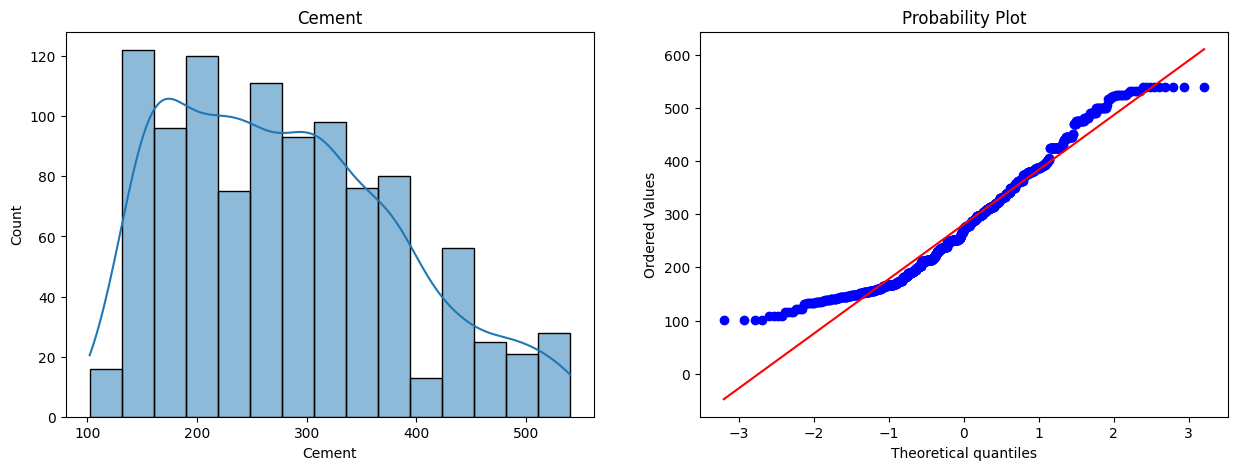

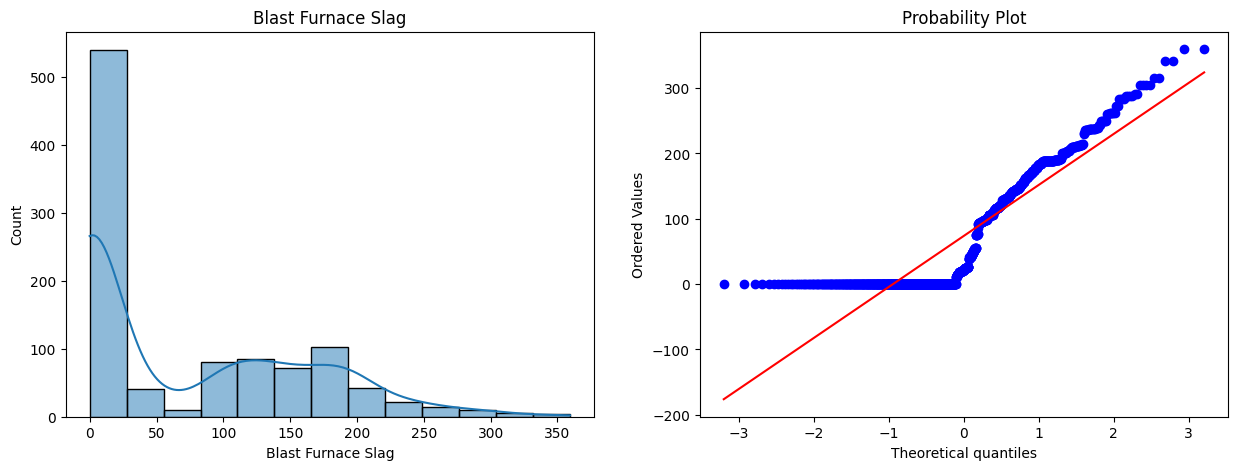

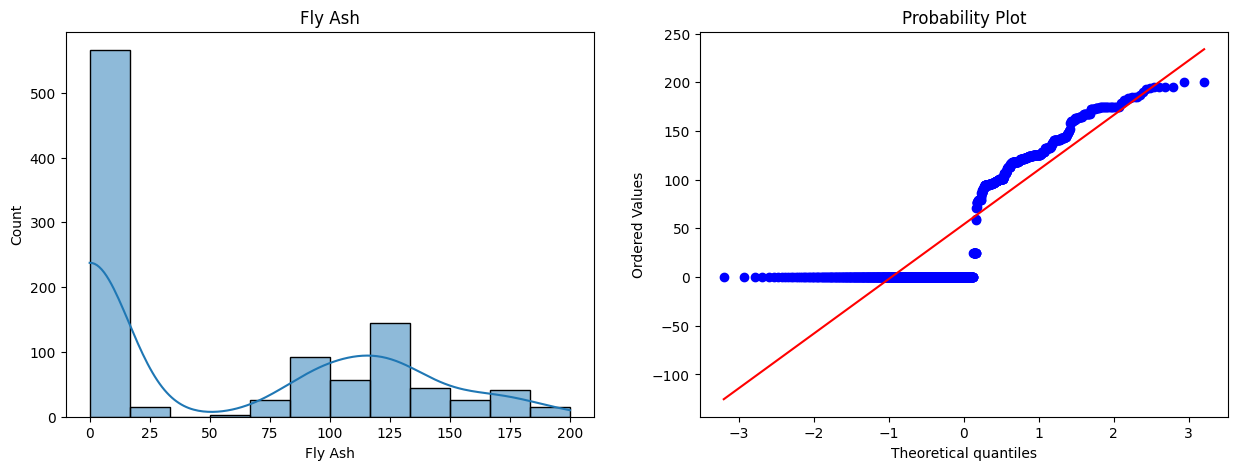

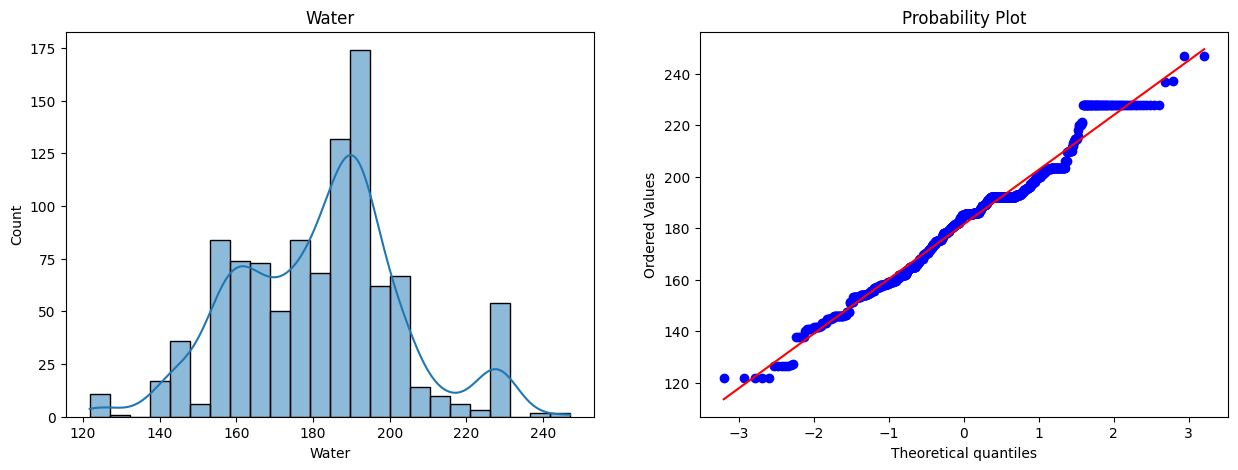

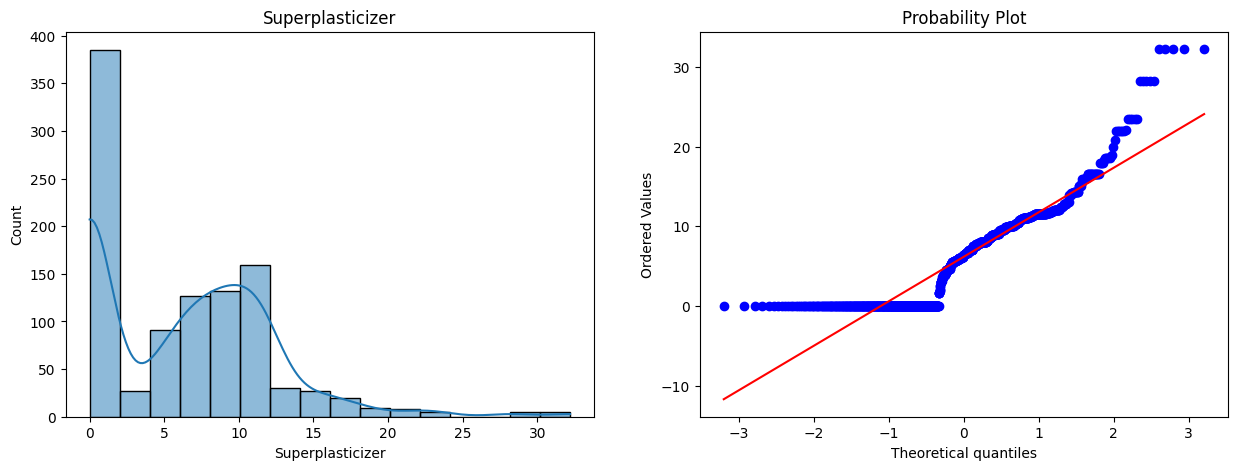

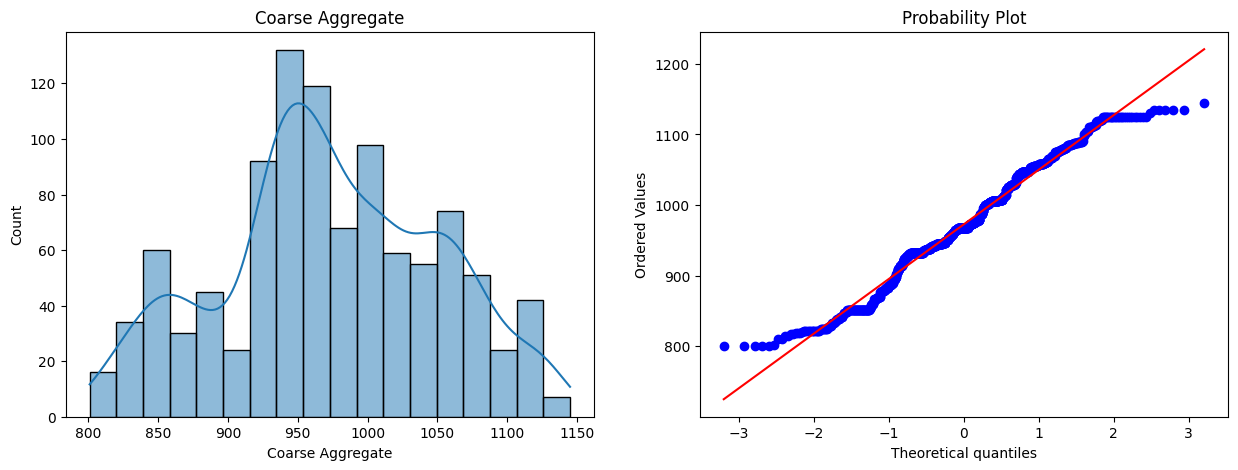

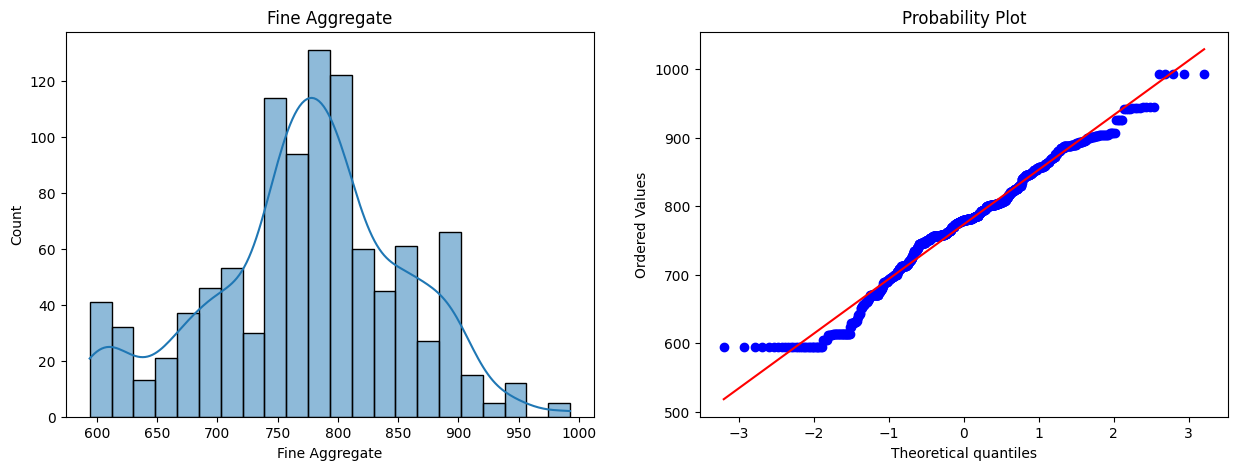

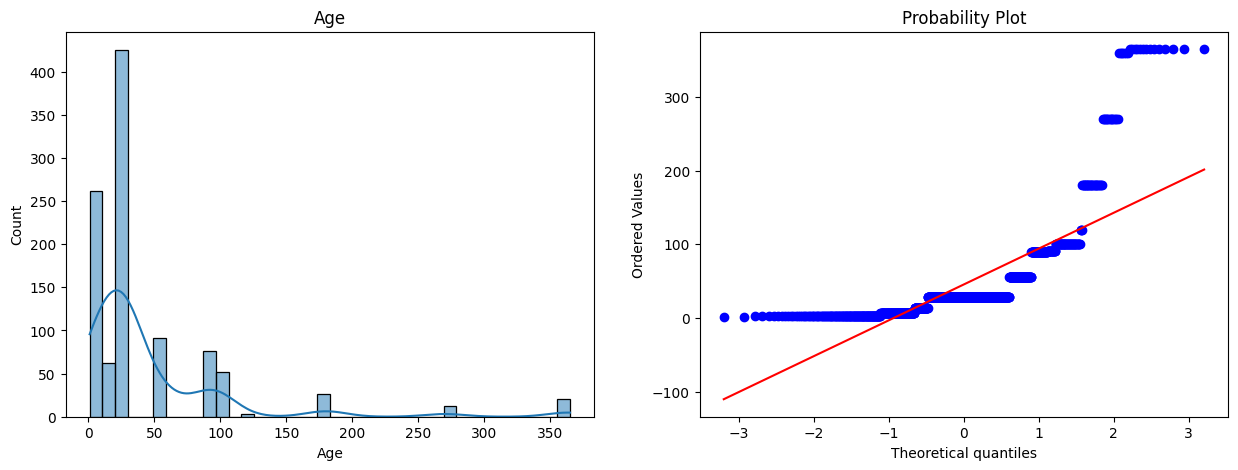

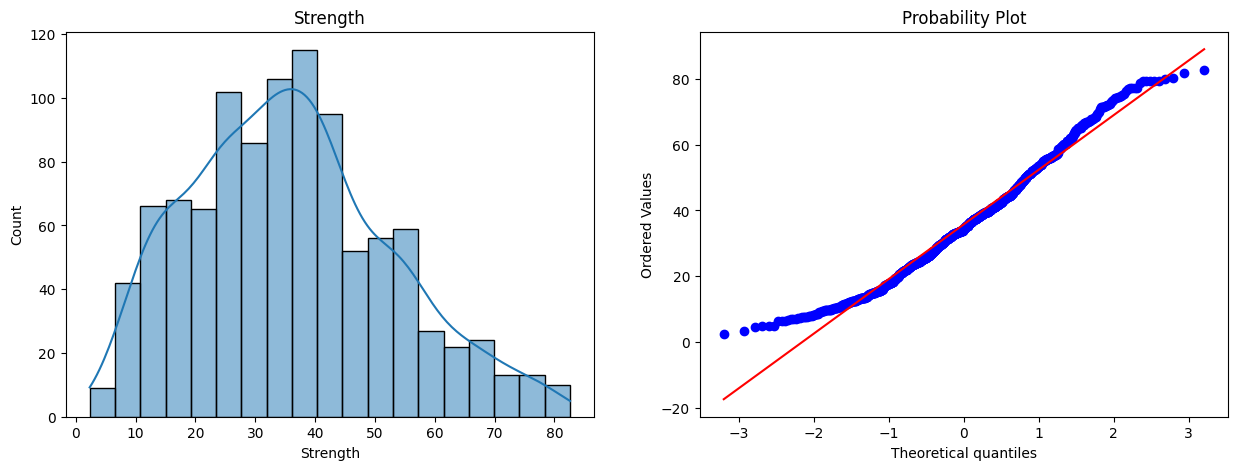

In [29]:
# now let us focus back on linear regression and try to improve it by transforming the data 

import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

for columns in df.columns:
    plt.figure(figsize=(15,5))
    plt.subplot(121)
    sns.histplot(df[columns], kde = True)
    plt.title(columns)
    
    plt.subplot(122)
    stats.probplot(df[columns], dist = "norm", plot = plt)
    plt.show()